### 🚀 **XGBoost (eXtreme Gradient Boosting)**

XGBoost is an optimized, distributed, and scalable gradient-boosting library designed to be highly efficient, flexible, and portable. It's an advanced implementation of **Gradient Boosting Machines (GBM)**, leveraging several innovative features to push performance boundaries.

---

#### 💡 **Core Idea: Gradient Boosting Refined**

At its heart, XGBoost is a form of **ensemble learning**, specifically **boosting**. It sequentially builds a series of weak learners (typically decision trees, often referred to as "regression trees") where each new tree tries to correct the errors of the *previous* trees. The "gradient" in Gradient Boosting refers to the fact that it uses **gradient descent** to minimize a loss function by iteratively adding models that predict the negative gradient (residuals) of the loss function.

XGBoost elevates this concept with key enhancements:

---

#### 📐 **The Objective Function (The "eXtreme" Part)**

Unlike traditional GBM which often optimizes a loss function directly, XGBoost optimizes a **regularized objective function**. This is a crucial distinction.

The objective function for the $t$-th iteration looks like this:

$$
\mathcal{L}^{(t)}(\hat{y}^{(t)}) = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)
$$

Where:
* $\mathcal{L}^{(t)}$: The objective function at iteration $t$.
* $l(y_i, \hat{y}_i)$: A differentiable **loss function** (e.g., Mean Squared Error for regression, Log Loss for classification) that measures the difference between the true label $y_i$ and the current prediction $\hat{y}_i$.
* $\hat{y}_i^{(t-1)}$: The prediction of the model from the *previous* $t-1$ iterations.
* $f_t(x_i)$: The new tree (weak learner) being added at the current iteration $t$, which predicts the residuals.
* $\Omega(f_t)$: The **regularization term** for the $t$-th tree. This is a key differentiator from basic GBM.

---

#### 📉 **Taylor Expansion of the Loss Function**

To optimize the loss function, XGBoost uses a **second-order Taylor expansion** (instead of just the first-order gradient used in traditional GBM):

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)
$$

Where:
* $g_i = \partial_{\hat{y}_i^{(t-1)}} l(y_i, \hat{y}_i^{(t-1)})$ is the **first-order gradient** (the "residual").
* $h_i = \partial_{\hat{y}_i^{(t-1)}}^2 l(y_i, \hat{y}_i^{(t-1)})$ is the **second-order gradient** (the Hessian).

By removing constant terms ($l(y_i, \hat{y}_i^{(t-1)})$ is just a value from the previous step), the simplified objective function for the $t$-th tree becomes:

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)
$$

This second-order approximation provides a more accurate direction for optimization and allows for faster convergence.

---

#### 🌳 **Regularization Term ($\Omega(f_t)$)**

This term penalizes the complexity of the trees, preventing overfitting. It has two parts:

$$
\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$

Where:
* $T$: Number of leaves in the tree.
* $w_j$: Output score (prediction) of the $j$-th leaf.
* $\gamma$: L1 regularization on the number of leaves. Penalizes the growth of trees (larger $\gamma$ means fewer leaves).
* $\lambda$: L2 regularization on the leaf weights. Penalizes large leaf scores (prevents individual trees from having too much influence).

By including regularization directly in the objective function, XGBoost can control tree complexity and prevent overfitting more effectively than traditional GBM.

---

#### 📉 **Optimal Leaf Weights & Split Finding**

After substituting the regularization term and simplifying, the objective function for a single tree with $T$ leaves can be rewritten to define the optimal weight $w_j^*$ for each leaf $j$ and the corresponding minimum loss for a given tree structure:

For a fixed tree structure (i.e., fixed splits), the optimal weight for each leaf $j$ is:

$$
w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}
$$

Where $I_j$ is the set of data points in leaf $j$.

The minimum loss for this tree structure with optimal leaf weights is:

$$
\text{Loss} = -\frac{1}{2} \sum_{j=1}^{T} \frac{\left(\sum_{i \in I_j} g_i\right)^2}{\sum_{i \in I_j} h_i + \lambda} + \gamma T
$$

**Split Finding (Greedy Algorithm):**
XGBoost greedily searches for the best split in a tree. For each potential split, it calculates the **gain**:

$$
\text{Gain} = \frac{1}{2} \left[ \frac{\left(\sum_{i \in I_L} g_i\right)^2}{\sum_{i \in I_L} h_i + \lambda} + \frac{\left(\sum_{i \in I_R} g_i\right)^2}{\sum_{i \in I_R} h_i + \lambda} - \frac{\left(\sum_{i \in I} g_i\right)^2}{\sum_{i \in I} h_i + \lambda} \right] - \gamma
$$

Where:
* $I_L$: Instances in the left child after split.
* $I_R$: Instances in the right child after split.
* $I$: Instances in the parent node before split.

XGBoost evaluates this gain for all possible splits and chooses the one that maximizes it. If the highest gain is less than $\gamma$, no split is made, and the node becomes a leaf. This is a form of **post-pruning** or direct tree complexity control built into the training.

---

#### ⚙️ **Key Features and Optimizations**

1.  **Regularization (L1 & L2):** As discussed, this is built directly into the objective function ($\Omega(f)$) to prevent overfitting.
2.  **Second-Order Gradients (Hessian):** Using both first ($g_i$) and second ($h_i$) order derivatives provides more precise direction for minimizing the loss, leading to faster and more accurate convergence.
3.  **Shrinkage (Learning Rate `eta`):**
    * Similar to gradient boosting, XGBoost uses a learning rate (`eta`, denoted as $\nu$ in some contexts) to scale the contribution of each tree to the final prediction.
    * $F(x) = F_{t-1}(x) + \nu \cdot f_t(x)$
    * This prevents overfitting by making the learning process more conservative.
4.  **Column Subsampling (`colsample_bytree`, `colsample_bylevel`):**
    * Randomly samples features (columns) for each tree or each level, similar to Random Forests.
    * Reduces overfitting and speeds up computation.
5.  **Row Subsampling (`subsample`):**
    * Randomly samples a fraction of the training data (rows) for each tree.
    * Also helps prevent overfitting and speeds up computation.
6.  **Handling Missing Values:**
    * XGBoost has a built-in mechanism to handle missing values by automatically learning the best direction for missing values to go (left or right branch) based on maximizing the gain.
7.  **Sparsity-Aware Split Finding:**
    * Efficiently handles sparse data (e.g., one-hot encoded features, text data) by only considering the non-missing entries when calculating splits.
8.  **Approximate Split Finding:**
    * For very large datasets that don't fit into memory, XGBoost can use an approximate algorithm to find splits using weighted quantiles, instead of enumerating all possible split points. This makes it highly scalable.
9.  **Cache-Aware Access:**
    * Optimizes memory usage by prefetching data into CPU caches, reducing memory access time and speeding up computation.
10. **Out-of-Core Computation:**
    * Handles datasets larger than memory by processing data in blocks on disk, allowing it to work with truly massive datasets.
11. **Parallelism:**
    * While boosting is inherently sequential (trees are built one after another), XGBoost parallelizes the tree construction *within* each tree's node splitting process. It can efficiently compute the gain for all possible splits across all features in parallel.

---

#### ⚖️ **XGBoost vs. Traditional Gradient Boosting Machines (GBM)**

| Feature                 | Traditional GBM (e.g., scikit-learn's `GradientBoostingClassifier`) | XGBoost                                                          |
| :---------------------- | :------------------------------------------------------------------ | :--------------------------------------------------------------- |
| **Objective Function** | Optimizes loss function (first-order gradients)                     | Optimizes **regularized** loss function (first & second-order gradients) |
| **Regularization** | Usually none built-in; relies on hyperparameters (`max_depth`, `n_estimators`, `learning_rate`) | Built-in L1 & L2 regularization ($\gamma$, $\lambda$) for complexity control |
| **Split Finding** | Exact greedy algorithm (can be slow for large data)                 | Exact greedy, **Approximate**, and **Sparsity-aware** algorithms |
| **Missing Values** | Requires explicit imputation                                        | Handled internally by learning optimal direction                 |
| **Tree Pruning** | Pre-pruning (stops growing a branch if conditions not met)          | Post-pruning (builds full tree, then prunes back if gain < $\gamma$) |
| **Parallelization** | Limited; typically sequential tree building                         | Parallelizes split finding *within* trees; supports distributed computing |
| **System Optimization** | Less emphasis on system-level optimizations                         | Cache-aware, Out-of-core computing, efficient block structure    |
| **Speed/Scalability** | Slower, less scalable for large datasets                            | Much faster, highly scalable                                     |
| **Performance** | Good, but often outperformed by XGBoost                             | State-of-the-art, very high predictive accuracy                  |

---

#### 📊 **When to Use XGBoost**

* **Tabular Data:** Excels on structured/tabular datasets, common in Kaggle competitions, finance, healthcare, etc.
* **High Performance Needed:** When you need top-tier predictive accuracy.
* **Large Datasets:** Its optimizations make it suitable for datasets that might overwhelm other algorithms.
* **Feature Importance:** Provides clear feature importance scores, aiding interpretability.
* **Robustness:** Less prone to overfitting than basic GBM due to built-in regularization.

---

#### ⚠️ **Considerations**

* **Hyperparameter Tuning:** While powerful, XGBoost has many hyperparameters that require careful tuning for optimal performance.
* **Interpretability:** While individual trees are interpretable, the ensemble of thousands of trees makes the overall model a "black box" similar to other boosting methods. Feature importance can help.
* **Computational Resources:** Can still be resource-intensive for extremely large datasets or very deep trees, although it's highly optimized.

---

## XGBoost Features

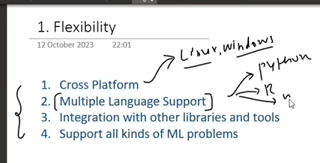

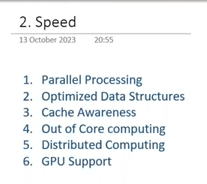

Xgboost stores the data in column block data structure. This helps significantly in parallel processing

### 🧠 Out-of-Core Computing in Machine Learning

---

## 🔹 What is Out-of-Core Computing?

**Out-of-core computing** refers to processing **datasets that do not fit into RAM** (main memory), by **loading small chunks at a time** from disk and computing incrementally.

> ⚠️ It’s a strategy to handle **very large datasets** that exceed your system's memory.

---

## 🔸 Why Do We Need It?

Most ML algorithms assume the **entire dataset fits in RAM**, but with:

* Terabytes of logs
* Millions of images
* Gigabytes of text

👉 **You can’t load everything into memory at once.**

---

## 🔹 How It Works

1. **Load a small batch (chunk) of data** into memory
2. **Perform partial computation** (e.g., update model or stats)
3. **Discard the chunk**, then load the next one
4. **Repeat** until entire dataset is processed

This is sometimes called **streaming** or **online processing**.

---

## 🔸 Techniques for Out-of-Core Learning

| Method                     | Description                                          |
| -------------------------- | ---------------------------------------------------- |
| **Mini-batch training**    | Use small data batches to update model incrementally |
| **Generators / Iterators** | Yield one batch at a time instead of loading all     |
| **Memory-mapped files**    | Use `numpy.memmap` to read disk data like arrays     |
| **Dask / Vaex**            | Scalable tools for distributed / chunked operations  |
| **Incremental estimators** | Models like `SGDClassifier`, `PartialFit`, etc.      |

---

## 🔹 Example in Scikit-learn

```python
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import load_svmlight_file

clf = SGDClassifier()

for X_batch, y_batch in data_stream():  # suppose you yield batches from disk
    clf.partial_fit(X_batch, y_batch, classes=[0, 1])
```

> `partial_fit()` trains incrementally — perfect for out-of-core.

---

## 🔸 Use Cases

* Huge **text datasets** (NLP)
* **Image classification** with large datasets (e.g., ImageNet)
* **Log processing**, **clickstream data**
* **Online learning systems** (e.g., recommendation engines)

---

## 🔹 Benefits

✅ Can train on **any size** of data
✅ Efficient use of memory
✅ Works well for **real-time or streaming applications**

---

## 🔸 Drawbacks

❌ Often **slower** than in-memory processing
❌ Requires algorithms that support incremental updates
❌ Harder to implement and debug

---

## 🧠 Summary

| Feature     | Description                                  |
| ----------- | -------------------------------------------- |
| Purpose     | Handle datasets too big for RAM              |
| Strategy    | Load & process chunks of data from disk      |
| Key Methods | `partial_fit`, generators, memmaps, Dask     |
| Algorithms  | SGD, Naive Bayes, k-Means (mini-batch), etc. |

---



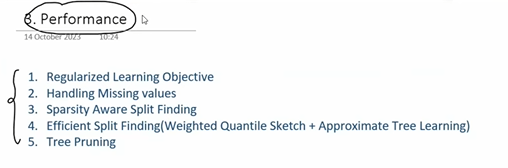

### 🧠 How Decision Trees Handle Missing Values

Decision trees can **handle missing values** in both the **training** and **prediction** phases — though the exact method depends on the implementation (e.g., CART, C4.5, XGBoost, etc.).

---

## 🔹 Why Are Missing Values a Problem?

A decision tree splits on features. If a feature is **missing**, it’s unclear:

> 👉 "Should this sample go to the left or the right child node?"

---

## 🔸 General Strategies to Handle Missing Values

### 1. **During Training: Skip or Impute**

#### a) **Imputation**

Fill missing values before training:

* Mean/Median/Mode
* k-NN imputation
* Iterative imputation

This is **common preprocessing** but not internal to decision trees.

#### b) **Surrogate Splits** (Used in CART, C4.5)

If the best feature to split is missing for some samples:

* Find another feature (**surrogate**) that **mimics the split**
* Use it as a backup to decide the path for missing values

📌 This allows trees to **still learn from all samples**.

---

## 🔸 During Prediction

### 2. **Handle Missing Values Dynamically**

#### a) **Surrogate Split (Again)**

If the test point is missing a value, the tree uses surrogate splits again (if they were computed during training).

#### b) **Weighted Path (Used in XGBoost, LightGBM)**

* If a feature value is missing at a split node:

  * The tree learns which child (left or right) is **more likely** to give better accuracy when feature is missing.
* The instance is routed **automatically to the learned "default" direction**.

✅ **Advantage**: No need to impute manually.

---

## 🔹 Example: XGBoost

```python
import xgboost as xgb
model = xgb.XGBClassifier()
model.fit(X_train, y_train)  # handles missing values (np.nan) internally
```

* XGBoost **automatically learns the best direction** for missing values during training.

---

## 🔸 Summary Table

| Method               | Description                                                       |
| -------------------- | ----------------------------------------------------------------- |
| Surrogate Splits     | Use backup features to mimic original split (CART, C4.5)          |
| Default Direction    | Tree learns best direction for missing values (XGBoost, LightGBM) |
| Preprocessing Impute | Fill missing values manually before training                      |

---

## 🧠 Final Notes

* **Scikit-learn’s DecisionTreeClassifier** (as of v1.0) **does not** support missing values — you must impute them manually.
* **XGBoost / LightGBM** handle `np.nan` **natively**.
* Surrogate splits are conceptually elegant but **computationally expensive** — hence not used in all libraries.

---


XGBoost sends the missing value to both the nodes and calculates te gains on both sides and keeps it in the node which gives more gain

### 🧠 Weighted Quantile Sketch + Approximate Tree Learning in XGBoost

*(For large datasets where exact split finding is infeasible)*

---

## 🔹 Why Do We Need Approximate Tree Learning?

XGBoost builds decision trees by **finding the best split** at each node, which normally requires:

* Sorting feature values
* Evaluating every possible split point

⛔ **Problem**: For huge datasets, this is **too slow and memory-heavy**.

✅ **Solution**: Use **approximate algorithms** to **estimate** the best split efficiently.

---

## 🔸 Key Idea: Summarize Data with a Quantile Sketch

To avoid sorting all feature values:

* Use a **quantile sketch** to summarize the **distribution of feature values**
* Pick **candidate split points** at key quantiles (like percentiles)
* Evaluate splits **only at these points**

---

## 🔹 What Is a Quantile Sketch?

A **quantile sketch** is a data structure that efficiently estimates **quantiles** (e.g., median, 90th percentile) from a data stream without storing all values.

In **XGBoost**, we use a **Weighted Quantile Sketch** to:

* Approximate the **cumulative distribution** of a feature
* Respect **data weights** (from boosting iterations)

---

## 🔸 What Makes XGBoost's Sketch "Weighted"?

In boosting, data points have **weights** (based on gradients and hessians).
XGBoost's sketch algorithm ensures:

```math
\text{Sketch respects: } \sum w_i, \quad \text{not just counts}
```

So quantiles are computed **w\.r.t. the total weight**, not just sample count.

---

## 🔹 Approximate Tree Learning Algorithm Steps

1. **Sketch Step**:

   * Use the **weighted quantile sketch** to find **split candidates** for each feature
   * Split candidates = values at estimated quantiles

2. **Proposal Step**:

   * Propose a small number of split points (e.g., 10 per feature)

3. **Prune Step**:

   * Evaluate each candidate using gradient/hessian statistics
   * Choose the best approximate split

4. **Repeat** recursively for each child node

---

## 🔸 Benefits

✅ Much faster than exact search
✅ Scales to **massive datasets**
✅ Works well with **sparse and weighted data**
✅ Reduces computation from **O(n log n)** to **O(k log n)** (k = # candidate splits)

---

## 🔹 In Practice

XGBoost uses this by default when:

* Dataset is large
* Or when you set `tree_method='approx'` manually

```python
xgb.XGBClassifier(tree_method='approx')
```

You can also use:

* `tree_method='hist'`: histogram-based (faster, GPU-compatible)
* `tree_method='gpu_hist'`: GPU histogram

---

## 🔸 Summary Table

| Concept                   | Description                                  |
| ------------------------- | -------------------------------------------- |
| Quantile Sketch           | Approximate summary of value distribution    |
| Weighted Sketch           | Uses instance weights for accurate quantiles |
| Approximate Tree Learning | Uses quantile-based split candidates         |
| Benefit                   | Faster split finding on large datasets       |

---



### 🌟 LightGBM — Light Gradient Boosting Machine (Full Explanation)

---

## 🧠 What is LightGBM?

**LightGBM** is a **fast, distributed, gradient boosting framework** developed by Microsoft. It builds decision trees **leaf-wise**, not level-wise like XGBoost, and uses **histogram-based optimization**.

> ⚡ **Designed for speed and memory efficiency**, especially on large datasets.

---

## 🔸 Key Features

| Feature                                     | Description                                    |
| ------------------------------------------- | ---------------------------------------------- |
| **Histogram-based splits**                  | Buckets continuous values to reduce complexity |
| **Leaf-wise tree growth**                   | Grows the leaf with max loss reduction first   |
| **Gradient-based One-Side Sampling (GOSS)** | Focuses on informative samples                 |
| **Exclusive Feature Bundling (EFB)**        | Merges sparse features to reduce dimensions    |

---

## 🔹 LightGBM vs XGBoost

| Aspect              | LightGBM                      | XGBoost                                |
| ------------------- | ----------------------------- | -------------------------------------- |
| Tree Growth         | Leaf-wise                     | Level-wise                             |
| Split Finding       | Histogram-based               | Exact / histogram / approx             |
| Categorical Support | Native support                | Requires encoding                      |
| Speed               | Faster on large & sparse data | Slower but more accurate in small data |
| Memory Use          | Lower                         | Higher                                 |

---

## 🔸 1. Leaf-Wise Tree Growth (With Depth Limit)

Instead of growing level by level (like XGBoost), LightGBM grows the **leaf that reduces loss the most**:

```
        Root
       /    \
     best   rest
     /  \
 better best
```

✅ **Pro:** Fast convergence, fewer iterations
❌ **Con:** May overfit → control with `max_depth`

---

## 🔸 2. Histogram-Based Split Finding

Instead of sorting all feature values:

1. Continuous values are **bucketed into bins** (e.g., 256)
2. Compute **gradients** for each bin
3. Use bin stats to find best split

✅ **Reduces memory & time** from O(#samples) to O(#bins)

---

## 🔸 3. GOSS — Gradient-based One-Side Sampling

In boosting, we use gradients to update models.

GOSS does this:

* Keep all data points with **large gradients**
* Randomly sample from **small-gradient** points

📌 This keeps informative examples and reduces computation.

---

## 🔸 4. EFB — Exclusive Feature Bundling

Many features in high-dimensional data are **sparse** and **never active together**.

EFB combines such mutually exclusive features into a **single feature** without loss.

→ Reduces effective number of features ⇒ faster training

---

## 🔹 Categorical Feature Handling

LightGBM **natively supports categorical variables**:

```python
lgb.Dataset(X, label=y, categorical_feature=['col1', 'col3'])
```

It finds optimal splits **without one-hot encoding**, improving:

* Memory usage
* Speed
* Model performance

---

## 🔸 Example: Basic LightGBM Classification

```python
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'verbosity': -1
}

model = lgb.train(params, train_data, valid_sets=[val_data], num_boost_round=100, early_stopping_rounds=10)
```

---

## 🔹 When to Use LightGBM?

✅ When your dataset is:

* Large
* High-dimensional
* Sparse (e.g., text, CTR data)
* Contains categorical features

✅ Also great for:

* Kaggle competitions
* Production pipelines

---

## 🔸 Summary Table

| Feature              | LightGBM Description     |
| -------------------- | ------------------------ |
| Tree Growth          | Leaf-wise (deep, greedy) |
| Speed                | Very fast                |
| Memory Use           | Low                      |
| Split Finding        | Histogram-based          |
| Handling Categorical | Native support           |
| Advanced Features    | GOSS, EFB                |

---


